# Ensemble training

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.sandbox.google.com/github/Drenderer/klax/blob/main/docs/examples/ensemble_training.ipynb)

This notebook demonstrates how to train an ensemble of MLPs with only single 
call to `klax.fit`.

This approach to create, train and evaluate multiple instances of the same 
model is inspired by [Equinox - Ensembling](https://docs.kidger.site/equinox/tricks/#ensembling).

To run it locally install klax with plotting capability via `pip install 'klax[plot]'`.

In [6]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

import klax

Let's first create some dummy data.

In [7]:
x = jnp.linspace(0, 3, 1000)
y = jnp.sin(x)

data = (x, y)

Then we create the ensemble of MLPs by vmapping over the MLP instantiation.
The result is an MLP where each array has an additional leading
"ensemble"-axis.

In [8]:
key = jr.key(0)
keys = jr.split(key, 10)


@eqx.filter_vmap
def make_ensemble(key):
    return klax.nn.MLP("scalar", "scalar", [16, 16], key=key)


mlp_ensemble = make_ensemble(keys)
mlp_ensemble

MLP(
  layers=(
    Linear(
      weight=f32[10,1,16],
      bias=f32[10,16],
      in_features='scalar',
      out_features=16,
      use_bias=True
    ),
    Linear(
      weight=f32[10,16,16],
      bias=f32[10,16],
      in_features=16,
      out_features=16,
      use_bias=True
    ),
    Linear(
      weight=f32[10,16,1],
      bias=f32[10,1],
      in_features=16,
      out_features='scalar',
      use_bias=True
    )
  ),
  activations=(
    <PjitFunction of <function softplus at 0x0000024CB5D6E2A0>>,
    <PjitFunction of <function softplus at 0x0000024CB5D6E2A0>>
  ),
  final_activation=<function MLP.<lambda>>,
  use_bias=True,
  use_final_bias=True,
  in_size='scalar',
  out_size='scalar',
  width_sizes=(16, 16)
)

To train the ensemble, we tell `klax.fit` that we would like to vmap the 
training over the ensemble, by setting `vmap_ensemble=True`.
Internally, this vmaps the initialization of the optimizer state, the parameter 
update function and the default metrics over the model parameters.

  0%|          | 0/10000 [00:00<?, ?it/s]

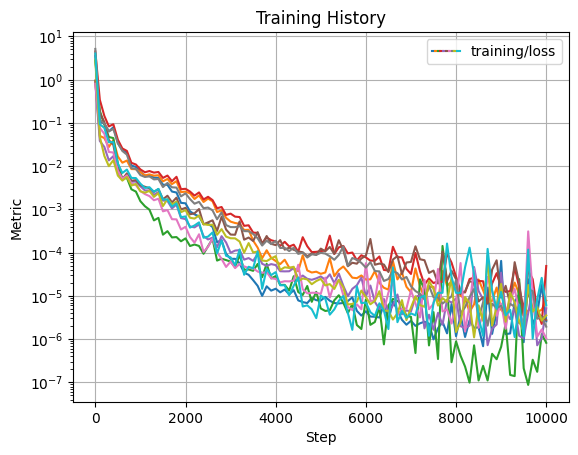

In [9]:
mlp_ensemble, history = klax.fit(
    mlp_ensemble,
    data,
    loss=klax.mse,
    steps=10_000,
    batch_size=32,
    vmap_ensemble=True,
    key=jr.key(0),
)

history.plot()
plt.show()

Note that the `"loss"` metric in the history also contains the ensemble axis.

In [12]:
final_losses = history["training/loss"].values[-1]
print(f"Final losses of the 10 MLPs: {final_losses}")

Final losses of the 10 MLPs: [2.5932063e-06 7.7781351e-06 8.2078662e-07 4.9082995e-05 5.1388520e-06
 2.7471133e-06 1.0477665e-06 1.9404301e-06 3.5353792e-06 6.0728589e-06]


To evaluate our ensemble, we cant just call `mlp_ensemble` directly, since the
internal logic of the MLP implementation does not expect the leading ensemble
axis of the parameter. Therefore, we simply write a tiny function to vmap the 
model evaluation over the leading parameter axis.

In [ ]:
@eqx.filter_vmap(in_axes=(eqx.if_array(0), None))
def evaluate_ensemble(model, x):
    return model(x)

Finally, we can plot the predictions of the individual MLPs.

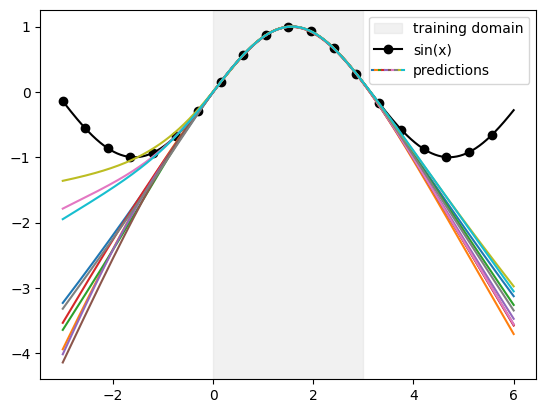

In [ ]:
x_test = jnp.linspace(-3, 6, 1000)
ys_pred = jax.vmap(evaluate_ensemble, in_axes=(None, 0))(mlp_ensemble, x_test)

train_domain = plt.axvspan(0, 3, color="lightgray", alpha=0.3)
(gt_line,) = plt.plot(
    x_test, jnp.sin(x_test), c="black", marker="o", markevery=50
)
pred_lines = plt.plot(x_test, ys_pred)
plt.legend(
    [train_domain, gt_line, tuple(pred_lines)],
    ["training domain", "sin(x)", "predictions"],
    handler_map={tuple: HandlerTuple(ndivide=None)},
)
plt.show()

One last thing: To split the ensemble into the individual models, you could do that like this:

In [ ]:
mlps = [
    jax.tree.map(lambda x: x[i] if eqx.is_array(x) else x, mlp_ensemble)
    for i in range(10)
]

mlps[0]

MLP(
  layers=(
    Linear(
      weight=f32[1,16],
      bias=f32[16],
      in_features='scalar',
      out_features=16,
      use_bias=True
    ),
    Linear(
      weight=f32[16,16],
      bias=f32[16],
      in_features=16,
      out_features=16,
      use_bias=True
    ),
    Linear(
      weight=f32[16,1],
      bias=f32[1],
      in_features=16,
      out_features='scalar',
      use_bias=True
    )
  ),
  activations=(
    <PjitFunction of <function softplus at 0x000002174849F1A0>>,
    <PjitFunction of <function softplus at 0x000002174849F1A0>>
  ),
  final_activation=<function MLP.<lambda>>,
  use_bias=True,
  use_final_bias=True,
  in_size='scalar',
  out_size='scalar',
  width_sizes=(16, 16)
)